In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

In [5]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [6]:
from sklearn.cluster import KMeans

kMeans = KMeans(
    n_clusters=2,
    random_state=42
)

In [7]:
y_kmeans = kMeans.fit_predict(X_scaled)

In [8]:
#evaluate
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y, y_kmeans))

[[175  37]
 [ 13 344]]


In [9]:
#classificaion report
from sklearn.metrics import classification_report


print(classification_report(y, y_kmeans))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [11]:
df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

In [12]:
df['Cluster'] = y_kmeans

In [13]:
df['True Label'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

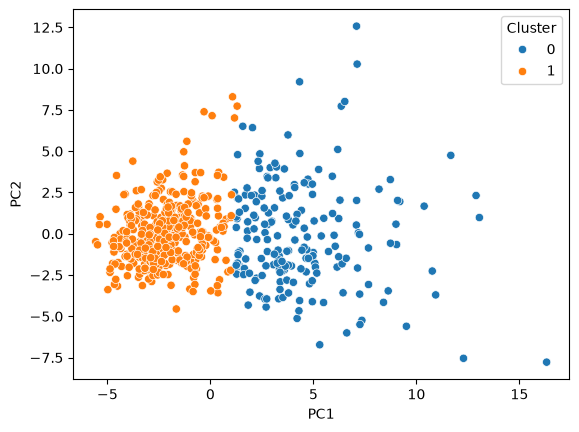

In [14]:
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Cluster'
)

<Axes: xlabel='PC1', ylabel='PC2'>

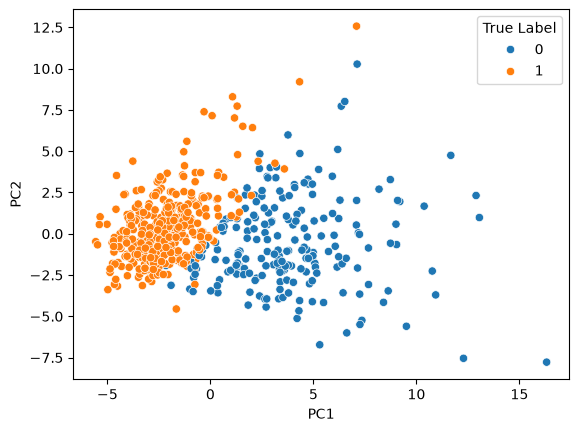

In [15]:
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='True Label'
)

In [22]:
kMeans.cluster_centers_

array([[ 0.98649786,  0.49202131,  1.01866689,  0.97479724,  0.5871176 ,
         1.014073  ,  1.14492245,  1.17028266,  0.60339021,  0.22927434,
         0.86311672,  0.04416341,  0.86446528,  0.8137762 ,  0.01228944,
         0.69281919,  0.63976499,  0.77166695,  0.13798752,  0.40384985,
         1.05221312,  0.51705679,  1.07769473,  1.01391704,  0.59804381,
         0.95285513,  1.05144274,  1.15328841,  0.5994129 ,  0.61362004],
       [-0.48677585, -0.24278217, -0.50264928, -0.48100231, -0.28970632,
        -0.50038248, -0.56494861, -0.57746231, -0.29773585, -0.11313275,
        -0.42589487, -0.02179192, -0.4265603 , -0.40154836, -0.00606408,
        -0.34186354, -0.31568456, -0.38077004, -0.06808833, -0.19927499,
        -0.51920227, -0.25513563, -0.53177588, -0.50030552, -0.29509774,
        -0.47017523, -0.51882214, -0.56907669, -0.29577329, -0.30278364]])

In [23]:
#convert cluster centers into PCA
centers = pca.transform(
    kMeans.cluster_centers_
)

In [26]:
centers

array([[ 4.40952193, -0.07888523],
       [-2.1758271 ,  0.03892499]])

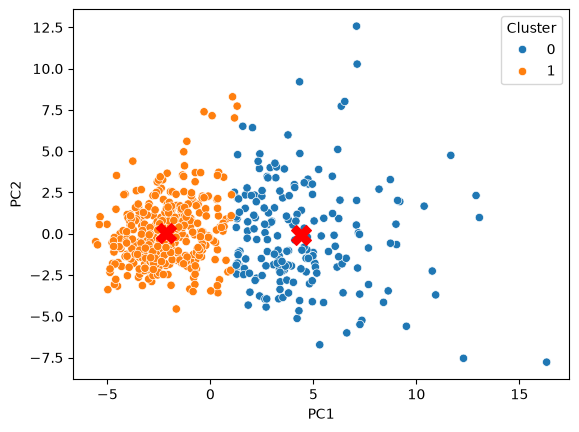

In [30]:
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Cluster',
)
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    c='red',
    marker='X'
)